# Analysis for PsyNamic Manuscript

In [63]:
import os
import pandas as pd
import sys
sys.path.append(os.path.abspath(".."))

def get_df_from_dir(file_dir: str):
    files = [f for f in os.listdir(file_dir) if os.path.isfile(os.path.join(file_dir, f))]
    df_list = []
    for file in files:
        file_path = os.path.join(file_dir, file)
        df = pd.read_csv(file_path)
        df_list.append(df)
    return pd.concat(df_list, ignore_index=True)


## Analysis of data fetching pipeline
### PubMed Fetch Results
How many articles were retrieved from PubMed via API until 31.12.2025?

In [64]:

# concate all files within the folder "../data/pubmed_fetch_results/"
df = get_df_from_dir("../data/pubmed_fetch_results/")
print(f'Total articles retrieved: {len(df)}')
df_2025_pubmed_fetch = df[df["entrez_year"] < 2026]
print(f'Total articles retrieved until 2025: {len(df_2025_pubmed_fetch)}')
print(f'Total articles without abstract until 2025: {len(df_2025_pubmed_fetch[df_2025_pubmed_fetch["abstract"].isna()])}')


Total articles retrieved: 1326
Total articles retrieved until 2025: 1172
Total articles without abstract until 2025: 15


How many articles were retrieved from PubMed via API in 2026?

In [65]:
df_2026_pubmed_fetch = df[df["entrez_year"] == 2026]
print(f'Total articles retrieved in 2026: {len(df_2026_pubmed_fetch)}')
print(f'Total articles without abstract in 2026: {len(df_2026_pubmed_fetch[df_2026_pubmed_fetch["abstract"].isna()])}')

Total articles retrieved in 2026: 154
Total articles without abstract in 2026: 1


Are there any articles in PubMed data that are already in the ASreview retrieved dataset?

In [66]:
as_file = "../data/manual/studies_relevant_with_info_20240101_00-00-00.csv"
df_as_relevant = pd.read_csv(as_file)

# Overlap according to PubMed IDs between ASreview dataset and PubMed API dataset
pubmed_ids = set(df_as_relevant['pubmed_id'].dropna().astype(int).tolist())
pubmed_ids_api = set(df_2025_pubmed_fetch['pubmed_id'].dropna().astype(int).tolist())

overlap_ids = pubmed_ids.intersection(pubmed_ids_api)
print(f'Number of articles in ASreview dataset that are also in PubMed API dataset: {len(overlap_ids)}')
print(df_as_relevant[df_as_relevant['pubmed_id'].isin(overlap_ids)][['pubmed_id', 'title']])
print(df_2025_pubmed_fetch[df_2025_pubmed_fetch['pubmed_id'].isin(overlap_ids)][['pubmed_id', 'title']])



Number of articles in ASreview dataset that are also in PubMed API dataset: 1
      pubmed_id                                              title
540  38283689.0  Intramuscular ketamine vs. midazolam for rapid...
      pubmed_id                                              title
1262   38283689  Intramuscular ketamine vs. midazolam for rapid...


Are there any duplicates in the 2025 PubMed API data? Or in the ASreview retrieved dataset?

In [67]:
duplicates = df_2025_pubmed_fetch[df_2025_pubmed_fetch.duplicated(subset=['pubmed_id'], keep=False)]
print(f'Number of duplicate articles in 2025 PubMed API dataset: {len(duplicates)}')

# Duplicates not counting nan
duplicates_no_nan = df_2025_pubmed_fetch[df_2025_pubmed_fetch.duplicated(subset=['pubmed_id'], keep=False) & df_2025_pubmed_fetch['pubmed_id'].notna()]
print(f'Number of duplicate articles in 2025 PubMed API dataset (excluding NaN pubmed_ids): {len(duplicates_no_nan)}')


Number of duplicate articles in 2025 PubMed API dataset: 0
Number of duplicate articles in 2025 PubMed API dataset (excluding NaN pubmed_ids): 0


### Relevant Studies from PubMed API
How many articles were classified relevant from PubMed API data until 31.12.2025?

In [68]:
rel_df = get_df_from_dir("../data/relevant_studies/")
rel_df_2025 = rel_df[rel_df["entrez_year"] <= 2025]
print(f'Total articles relevant until 2025: {len(rel_df_2025)}')
# without abstracts
print(f'Total articles relevant without abstract until 2025: {len(rel_df_2025[rel_df_2025["abstract"].isna()])}')
# relevant where prediction = 1
df_2025_relevant = rel_df_2025[rel_df_2025["prediction"] == 1]
print(f'Total articles classified relevant until 2025: {len(df_2025_relevant)}')
print(f'Total articles classified irrelevant until 2025: {len(rel_df_2025[rel_df_2025["prediction"] == 0])}')

Total articles relevant until 2025: 1157
Total articles relevant without abstract until 2025: 0
Total articles classified relevant until 2025: 634
Total articles classified irrelevant until 2025: 523


### Total relevant studies up until 31.12.2025


In [69]:
df_2025_relevant, df_as_relevant
# add acolumn pubmed_id to df_2025_relevant, containing the id
df_2025_relevant['pubmed_id'] = df_2025_relevant['id']

merged_df = pd.concat([df_2025_relevant, df_as_relevant], ignore_index=True)
# remove duplicates based on pubmed_id (NaNs should not be considered duplicates)
# keep all rows where pubmed_id is NaN; drop duplicates only among non-NaN ids
mask_drop = merged_df['pubmed_id'].notna() & merged_df.duplicated(subset=['pubmed_id'], keep='first')
merged_df = merged_df[~mask_drop].reset_index(drop=True)
# print how many were dropped
num_dropped = mask_drop.sum()
print(f'Number of duplicate articles dropped from merged dataset based on pubmed_id: {num_dropped}')

print(f'Total ASreview relevant articles: {len(df_as_relevant)}')
print(f'Total relevant articles from PubMed API until 2025: {len(df_2025_relevant)}')

print(f'Total articles in merged dataset: {len(merged_df)}')
print(f'Unique study ids: {len(merged_df["id"].unique())}')

Number of duplicate articles dropped from merged dataset based on pubmed_id: 1
Total ASreview relevant articles: 3313
Total relevant articles from PubMed API until 2025: 634
Total articles in merged dataset: 3946
Unique study ids: 3946


/tmp/ipykernel_598098/148333110.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Are there duplicates in merged dataset?

In [70]:
# check how many duplicates are in merged_df based on same title and year, not considerin year NaN
duplicates_merged = merged_df[merged_df.duplicated(subset=['title', 'year'], keep=False) & merged_df['year'].notna()]
print(f'Number of duplicate articles in merged dataset based on title and year: {len(duplicates_merged)}')
# print those duplicates
print(duplicates_merged[['id', 'title', 'year', 'pubmed_id']])


# check how many duplicates based on title only
duplicates_title = merged_df[merged_df.duplicated(subset=['title'], keep=False)]
print(f'Number of duplicate articles in merged dataset based on title only: {len(duplicates_title)}')
print(duplicates_title[['id', 'title', 'year', 'pubmed_id']])

# write duplicates to csv
duplicates_title.to_csv("../data/duplicates_title.csv", index=False)

Number of duplicate articles in merged dataset based on title and year: 2
        id                                              title    year  \
1218  8180  Relationship of ketamine's antidepressant and ...  2013.0   
1288  8179  Relationship of ketamine's antidepressant and ...  2013.0   

      pubmed_id  
1218        NaN  
1288        NaN  
Number of duplicate articles in merged dataset based on title only: 24
            id                                              title    year  \
127   40800803  Dynamic medial parietal and hippocampal deacti...     NaN   
562   38464275  Dynamic medial parietal and hippocampal deacti...     NaN   
796       3179  Psilocybin can occasion mystical-type experien...  2006.0   
799       3180  Psilocybin can occasion mystical-type experien...  2007.0   
887       2256  Efficacy of Intravenous Ketamine in Adolescent...  2021.0   
889       2257  Efficacy of Intravenous Ketamine in Adolescent...  2022.0   
918       2387  A Study of the Efficacy an

Do the numbers add up to the PsyNamic Webapp dashboard?

In [71]:
df_2026_relevant = rel_df[(rel_df["entrez_year"] == 2026) & (rel_df["prediction"] == 1)]
print(f'Total articles classified relevant in 2026: {len(df_2026_relevant)}')

len(merged_df)+len(df_2026_relevant)


Total articles classified relevant in 2026: 78


4024

## Analysis of predictions
### Classification predictions

In [72]:
merged_df.head()

,id,text,prediction,probability,keywords,pubmed_id,pubmed_url,doi,pub_date,entrez_year,...,custom6,custom5,note,custom7,original_publication,custom3,asreview_prior,exported_notes_1,included,asreview_ranking
0,41475562,A systematic review of ketamine and esketamine...,1.0,"[0.0032017924822866917, 0.9967982172966003]","['Depressive disorder', 'Drug administration s...",41475562.0,https://pubmed.ncbi.nlm.nih.gov/41475562/,10.1016/j.jad.2025.121081,2026-04-15,2025.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,41468673,Challenges of enrolling participants with alco...,1.0,"[0.0032391853164881468, 0.9967607855796814]","['Alcohol use disorder', 'Clinical trials', 'E...",41468673.0,https://pubmed.ncbi.nlm.nih.gov/41468673/,10.1016/j.genhosppsych.2025.12.019,2026-01-01,2025.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,41459830,Comparing single- and repeat-dose psilocybin w...,1.0,"[0.002905561588704586, 0.9970943927764893]","['diphenhydramine', 'headache disorders', 'mig...",41459830.0,https://pubmed.ncbi.nlm.nih.gov/41459830/,10.1111/head.70024,2025-12-29,2025.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,41456567,Single fixed-dose intranasal racemic ketamine ...,1.0,"[0.002612984273582697, 0.9973869919776917]","['Acute psychiatry', 'Ketamine', 'Mood disorde...",41456567.0,https://pubmed.ncbi.nlm.nih.gov/41456567/,10.1016/j.psychres.2025.116909,2026-03-01,2025.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,41450831,Acute and post-dosing effects of single-dose p...,1.0,"[0.004768026061356068, 0.9952319264411926]","['acute effects', 'adult psychiatry', 'interpr...",41450831.0,https://pubmed.ncbi.nlm.nih.gov/41450831/,10.3389/fpsyt.2025.1726818,2025-01-01,2025.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
class_data = pd.read_csv("../analysis/export/classification_data.csv")
ner_data = pd.read_csv("../analysis/export/ner_data.csv")
dosage_ner_data = pd.read_csv("../analysis/export/dosage_data.csv")
study_data = pd.read_csv("../analysis/export/study_data.csv")

# check if all ids of merged_df are in study_data
ids_merged = set(merged_df['id'].tolist())
ids_study_data = set(study_data['study_id'].tolist())
ids_not_in_study_data = ids_merged - ids_study_data
print(f'Number of ids in merged dataset that are not in study_data: {len(ids_not_in_study_data)}')
print(f'Number of ids in study_data that are not in merged dataset: {len(ids_study_data - ids_merged)}')

# Only keep rows in study_data where study_id is in merged_df
study_data_2025 = study_data[study_data['study_id'].isin(ids_merged)].reset_index(drop=True)
print(len(study_data_2025))

class_data_2025 = class_data[class_data['study_id'].isin(ids_merged)].reset_index(drop=True)
ner_data_2025 = ner_data[ner_data['study_id'].isin(ids_merged)].reset_index(drop=True)
dosage_ner_data_2025 = dosage_ner_data[dosage_ner_data['Study_ID'].isin(ids_merged)].reset_index(drop=True)


Number of ids in merged dataset that are not in study_data: 0
Number of ids in study_data that are not in merged dataset: 76
3946


In [74]:
class_data_2025.head()

,study_id,task,label,probability,model,is_multilabel
0,305,Condition,Psychiatric condition,1.0,manual_annotation,True
1,305,Condition,Depression,1.0,manual_annotation,True
2,777,Condition,Psychiatric condition,1.0,manual_annotation,True
3,777,Condition,Depression,1.0,manual_annotation,True
4,1240,Condition,Psychiatric condition,1.0,manual_annotation,True


In [75]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

df = class_data_2025.copy()
# Count studies per task per label
label_counts = df.groupby(['task', 'label'])['study_id'].nunique().reset_index(name='count')

# Get list of unique tasks
tasks = label_counts['task'].unique()
n_tasks = len(tasks)

# Create subplots: one row per task
fig = make_subplots(
    rows=n_tasks, cols=1,
    shared_xaxes=False,  # each task has its own x-axis
    vertical_spacing=0.02,
    subplot_titles=tasks
)

# Add a bar for each task
for i, task in enumerate(tasks, 1):
    task_data = label_counts[label_counts['task'] == task]
    fig.add_trace(
        go.Bar(
            x=task_data['count'],
            y=task_data['label'],
            orientation='h',
            text=task_data['count'],
            textposition='inside',
            showlegend=False
        ),
        row=i, col=1
    )

# Update layout for A4 landscape style
fig.update_layout(
    height=250*n_tasks,  # scale height based on number of tasks
    width=1000,
    title="Label Distribution per Task",
    template="plotly_white"
)

fig.show()

In [76]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from style.colors import get_color_mapping
import numpy as np

# Count studies per task per label
label_counts = df.groupby(['task', 'label'])['study_id'].nunique().reset_index(name='count')

# Compute total studies per task for percentages
task_totals = label_counts.groupby('task')['count'].sum().reset_index(name='total')
label_counts = label_counts.merge(task_totals, on='task')
label_counts['percent'] = (label_counts['count'] / label_counts['total'] * 100).round(1)

tasks = label_counts['task'].unique()
n_tasks = len(tasks)
vertical_spacing = min(0.04, 1/(n_tasks-1))

# Create subplots
fig = make_subplots(
    rows=n_tasks, cols=1,
    shared_xaxes=False,
    vertical_spacing=vertical_spacing,
    subplot_titles=tasks,
    row_heights=[0.8]*n_tasks  # leave room for legends
)

# Add bars + mini-legend per task
for i, task in enumerate(tasks, 1):
    task_data = label_counts[label_counts['task'] == task].copy()
    task_data = task_data.sort_values(by='count', ascending=False)
    
    labels_list = task_data['label'].tolist()
    color_map = get_color_mapping(task, labels_list, type='rgb')
    
    # Add stacked bars
    for idx, row in task_data.iterrows():
        fig.add_trace(
            go.Bar(
                y=[task],
                x=[row['count']],
                name=row['label'],
                orientation='h',
                text=f"{row['count']} ({row['percent']}%)",
                textposition='inside',
                marker_color=color_map[row['label']],
                showlegend=False
            ),
            row=i, col=1
        )
    
    # Add mini-legend using Scatter traces
    total_width = sum(task_data['count']) * 1.1
    x_positions = np.linspace(0, total_width, len(labels_list))
    
    for x, lbl in zip(x_positions, labels_list):
        fig.add_trace(
            go.Scatter(
                x=[x],
                y=[-1],  # below bars, outside visible axis
                mode='markers+text',
                marker=dict(color=color_map[lbl], size=15, symbol='square'),
                text=[lbl],
                textposition='middle right',
                showlegend=False,
                hoverinfo='none'
            ),
            row=i, col=1
        )

# Hide all y-axis ticks for mini-legend and remove extra space
fig.update_yaxes(automargin=True, showticklabels=True)  # main bars visible
fig.update_xaxes(showticklabels=False)

# Make sure negative y values (for legend) do not show axis
fig.update_layout(
    barmode='stack',
    height=300*n_tasks,
    width=1000,
    title="Stacked Bar Chart with Mini-Legends per Task",
    template="plotly_white",
    margin=dict(t=100, b=100),
)

fig.show()

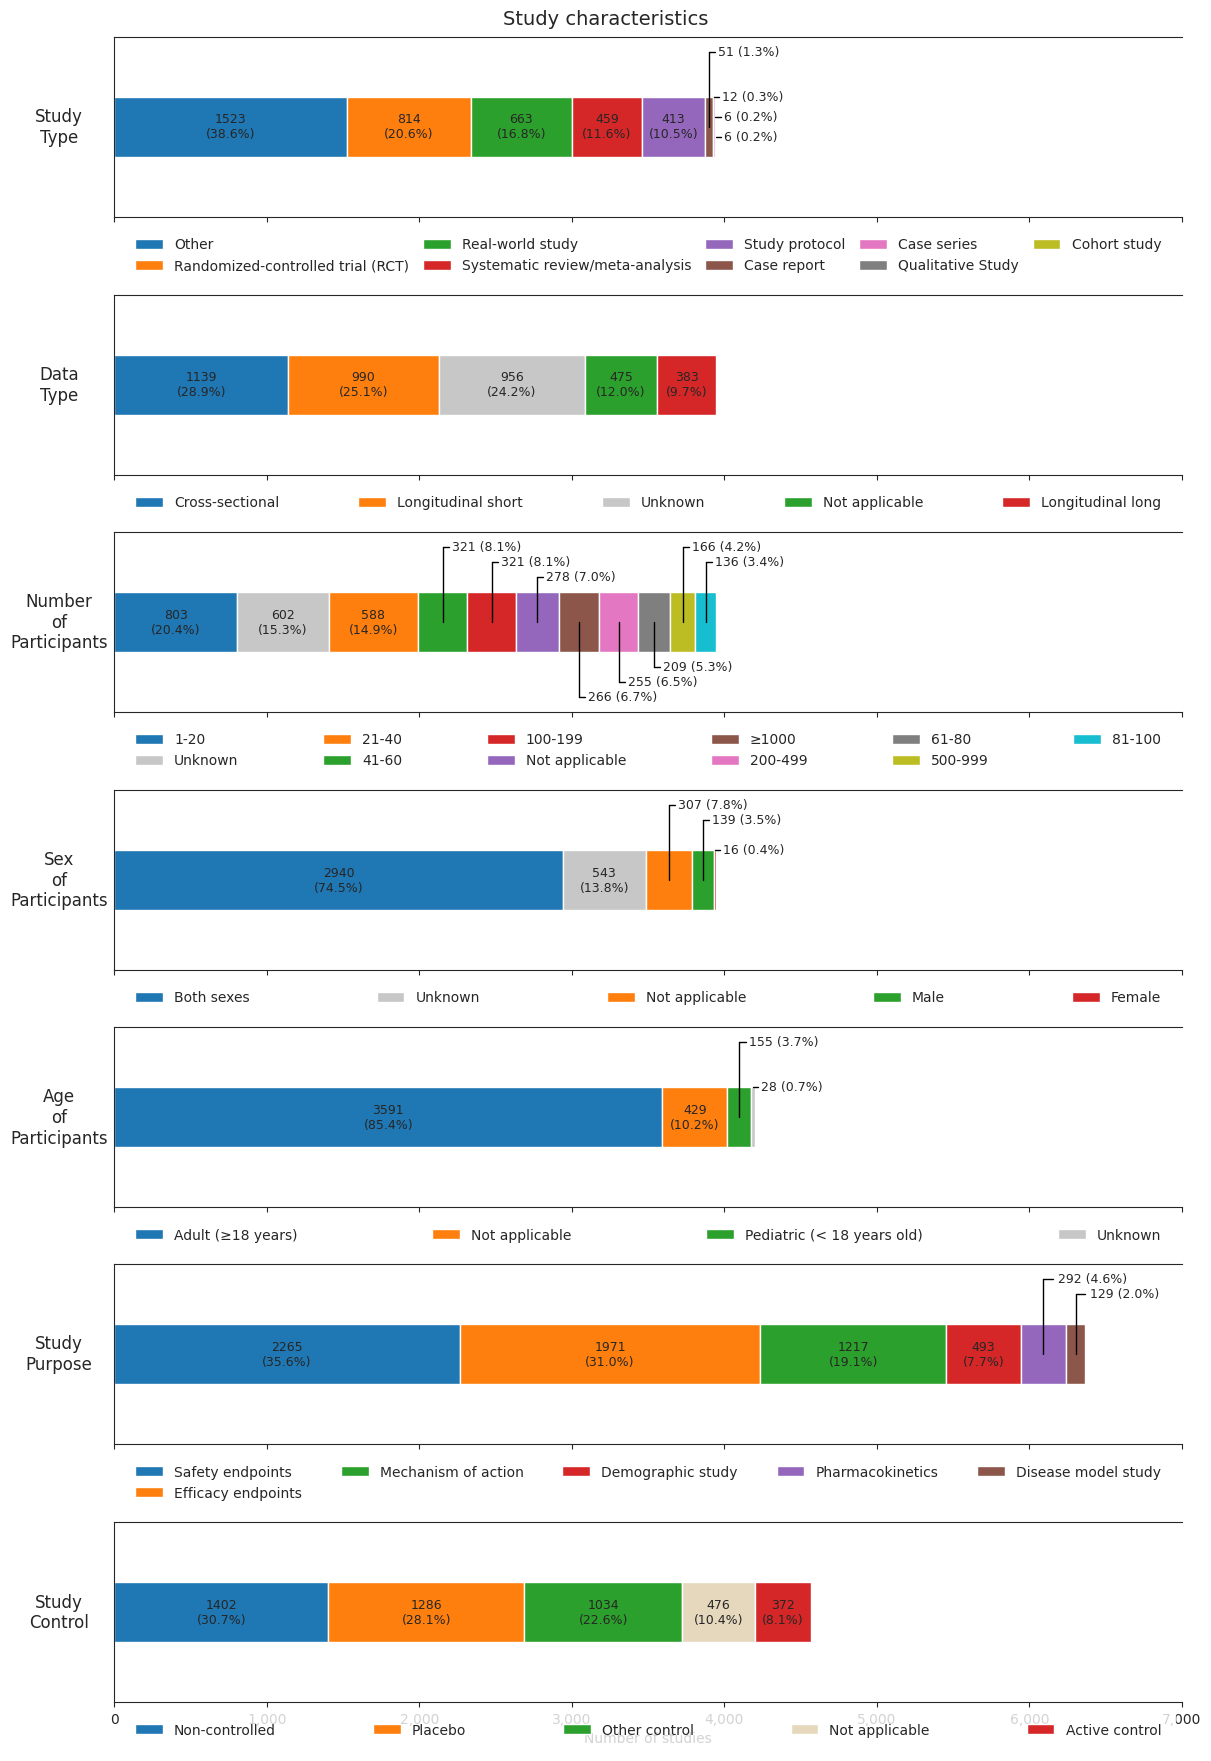

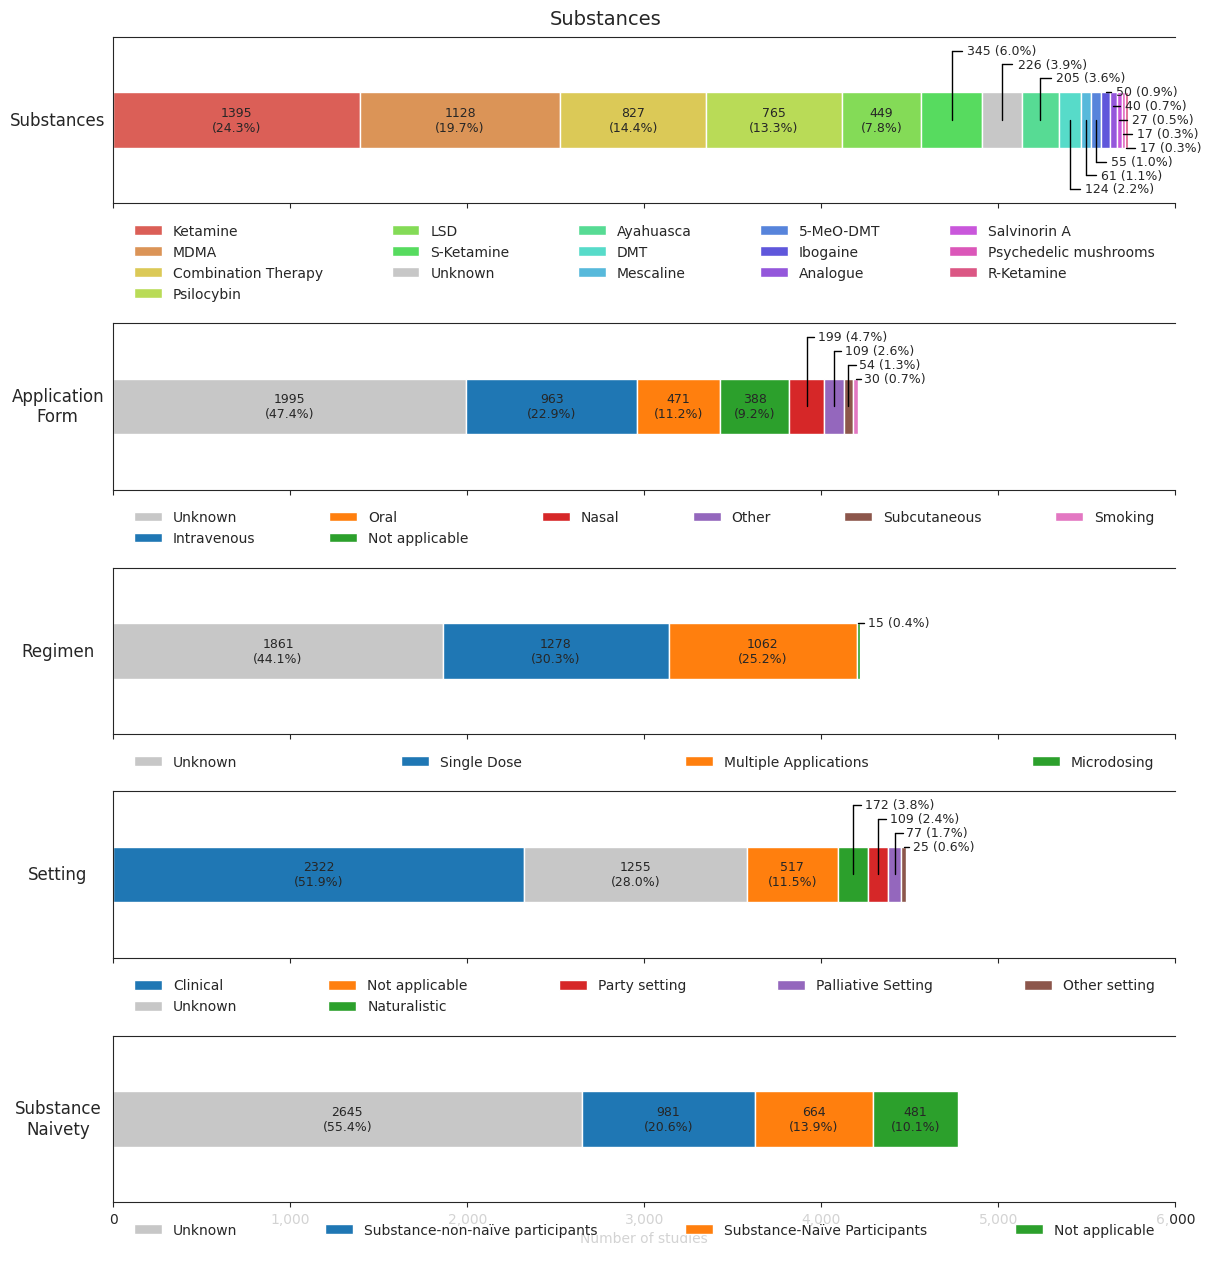

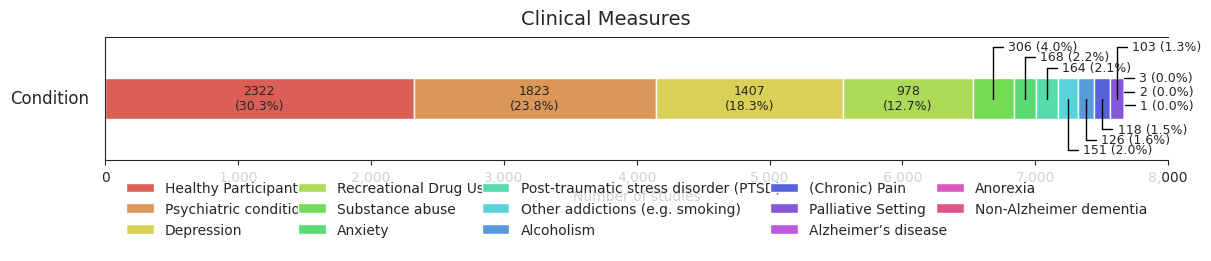

In [77]:
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd
from style.colors import GREY, BROWN
sns.set_style("white")

SKIP_TASKS = ['Clinical Trial Phase', 'Study Conclusion']

TASK_ORDER_GROUP = [
    ['Study Type', 'Data Type', 'Data collection', 'Number of Participants', 'Sex of Participants', 'Age of Participants', 'Study Purpose', 'Study Control'],
    ['Substances', 'Application Form', 'Regimen', 'Setting', 'Substance Naivety'],
    ['Condition', 'Outcome']
]

GROUPS = ['Study characteristics', 'Substances','Clinical Measures']

df = class_data_2025.copy()


label_counts = df.groupby(['task', 'label'])['study_id'].nunique().reset_index(name='count')

task_totals = label_counts.groupby('task')['count'].sum().reset_index(name='total')
label_counts = label_counts.merge(task_totals, on='task')
label_counts['percent'] = (label_counts['count'] / label_counts['total'] * 100).round(1)

tasks = [t for t in label_counts['task'].unique() if t not in SKIP_TASKS]
n_tasks = len(tasks)


for group_name, (group_idx, group_tasks) in zip(GROUPS, enumerate(TASK_ORDER_GROUP)):

    group_df = label_counts[label_counts['task'].isin(group_tasks)].copy()
    max_total = group_df['total'].max() 

    # keep only tasks that exist in your data
    group_tasks_present = [t for t in group_tasks if t in group_df['task'].unique()]
    n_tasks_group = len(group_tasks_present)

    if n_tasks_group == 0:
        continue

    fig, axes = plt.subplots(
        n_tasks_group,
        1,
        figsize=(12, 2.5 * n_tasks_group),
        sharex=True,
        constrained_layout=True,
    )
   

    if n_tasks_group == 1:
        axes = [axes]

    for ax, task in zip(axes, group_tasks_present):

        task_data = group_df[group_df['task'] == task].copy()
        task_data = task_data.sort_values(by='count', ascending=False).reset_index(drop=True)

        total = task_data['count'].sum()

    
        SMALL_THR = 350
        TINY_THR = 50

        LINE_LEN = 0.01 * total
        TEXT_GAP = 0.005 * total

        labels_list = task_data['label'].tolist()

       
        palette = {}
        if 'Unknown' in labels_list:
            palette['Unknown'] = mcolors.to_hex(GREY)
        elif 'Not applicable' in labels_list:
            palette['Not applicable'] = mcolors.to_hex(BROWN)

        remaining_labels = [l for l in labels_list if l not in palette]

        sns_palette = (
            sns.color_palette("hls", len(remaining_labels))
            if len(remaining_labels) > 10
            else sns.color_palette("tab10", len(remaining_labels))
        )

        for color, lbl in zip(sns_palette, remaining_labels):
            palette[lbl] = mcolors.to_hex(color)


        left = 0
        bars = []
        legend_labels = []

        label_idx = 0
        tiny_idx = 0

        tiny_mask = task_data['count'] < TINY_THR
        tiny_total = tiny_mask.sum()
        tiny_y_positions = (
            np.linspace(0.3 / 2 - 0.05, -0.3 / 2 + 0.05, tiny_total + 1)
            if tiny_total > 0 else []
        )

        y_top = [0.25, 0.20, 0.15]
        y_bottom = [-0.25, -0.20, -0.15]

        for idx, row in task_data.iterrows():
            width = row['count']

            bar = ax.barh(
                y=0,
                width=width,
                left=left,
                height=0.2,
                color=palette[row['label']],
                edgecolor='white'
            )

            bars.append(bar[0])
            legend_labels.append(row['label'])

            x_center = left + width / 2

            if width < SMALL_THR:
                text = f"{row['count']} ({row['percent']}%)"

                if width > TINY_THR:

                    group = (label_idx // 3) % 2
                    pos_in_group = label_idx % 3

                    y_pos = y_top[pos_in_group] if group == 0 else y_bottom[pos_in_group]

                    line_end_x = x_center + LINE_LEN
                    text_x = line_end_x + TEXT_GAP

                    ax.plot([x_center, x_center], [0, y_pos], color='black', lw=1)
                    ax.plot([x_center, line_end_x], [y_pos, y_pos], color='black', lw=1)

                    ax.text(text_x, y_pos, text, ha='left', va='center', fontsize=9)

                    label_idx += 1

                else:
                    if tiny_total > 0:
                        y_pos = tiny_y_positions[tiny_idx]

                        line_end_x = left + LINE_LEN
                        text_x = line_end_x + TEXT_GAP

                        ax.plot([x_center, line_end_x], [y_pos, y_pos], color='black', lw=1)

                        ax.text(text_x, y_pos, text, ha='left', va='center', fontsize=9)

                        tiny_idx += 1

            else:
                text = f"{row['count']}\n({row['percent']}%)"
                ax.text(x_center, 0, text, ha='center', va='center', fontsize=9)

            left += width

        ax.set_xlim(0, max_total*1.01)
        ax.set_ylim(-0.3, 0.3)
        ax.set_yticks([])
        ax.set_ylabel(task.replace(' ', '\n'), rotation=0, labelpad=40, fontsize=12, va='center')
        # add tick marks for 1000, 2000, etc.
        upper = int(np.ceil(max_total / 1000.0)) * 1000
        ticks = np.arange(0, upper + 1, 1000)
        ax.set_xticks(ticks)
        ax.set_xticklabels([int(x) for x in ticks])
        ax.tick_params(axis='x', which='both', labelbottom=True, bottom=True)
        ax.spines['right'].set_visible(False)

        # check max length of labels
        if any(len(lbl) > 15 for lbl in labels_list):
            ncol = 5
        elif any(len(lbl) > 12 for lbl in labels_list):
            ncol = 6
        else:
            ncol = 7

        ax.legend(
            bars,
            legend_labels,  # different per plot
            # title='Labels',
            loc='upper center',  # anchor point
            bbox_to_anchor=(0, -0.1, 1, 0.1),  # (x0, y0, width, height)
            mode='expand',  # makes legend stretch horizontally
            ncol=ncol,
            frameon=True,
            shadow=False,
            facecolor='white',
            edgecolor='white',
            # sett padding to the bottom
            columnspacing=0.5,
            borderpad=1
        )
        # fig.set_constrained_layout_pads(hspace=0.2)
    for a in axes:
        a.set_xticks(ticks)
        a.tick_params(axis='x', which='both', labelbottom=False, bottom=True)

    axes[-1].set_xticklabels([f"{int(x):,}" for x in ticks])
    axes[-1].tick_params(axis='x', which='both', labelbottom=True, bottom=True)
    axes[-1].set_xlabel('Number of studies')


    plt.suptitle(f"{group_name}", fontsize=14)
    plt.show()

In [78]:
from plotly.subplots import make_subplots

def shorten_label(label, max_len=10):
    if len(label) <= max_len:
        return label
    return label[:max_len] + "..."


tasks = label_counts['task'].unique()
n_tasks = len(tasks)

fig = make_subplots(
    rows=n_tasks, cols=1,
    shared_xaxes=False,
    vertical_spacing=0.02,
    subplot_titles=tasks
)

for i, task in enumerate(tasks, 1):
    show_cb = True if i == 1 else False

    task_data = label_counts[label_counts['task'] == task]
    fig.add_trace(
        go.Heatmap(
            z=[task_data['count']],
            x=task_data['label'].apply(lambda x: shorten_label(str(x), 10)),
            y=[task],
            colorscale='Blues',
            showscale=show_cb,
            text=task_data['count'],
            texttemplate="%{text}"
        ),
        row=i, col=1
    )

# Add a colorbar for the heatmap


fig.update_layout(
    title="Mini Heatmaps: Label Distribution per Task",
    height=200*n_tasks,
    width=1000
)
fig.show()

In [79]:
fig = make_subplots(
    rows=len(tasks), cols=1,
    shared_xaxes=False,
    vertical_spacing=0.02,
    subplot_titles=tasks
)

for i, task in enumerate(tasks, 1):
    task_data = label_counts[label_counts['task'] == task]
    for _, row in task_data.iterrows():
        fig.add_trace(
            go.Scatter(
                x=[0, row['count']],
                y=[row['label'], row['label']],
                mode='lines+markers',
                line=dict(color='skyblue', width=3),
                marker=dict(size=10, color='skyblue')
            ),
            row=i, col=1
        )

fig.update_layout(
    title="Lollipop Plot: Label Frequency per Task",
    height=200*len(tasks),
    width=1000,
    showlegend=False
)
fig.show()

### NER predictions

Preprocessing:
* remove dosages with several substances (execpt if it is Ketamin + S-Ketamine or in combination with Combination Therapy)
* remove any time related dosages (as they cannot be compared)

In [80]:
dosage_ner_data_2025.head()


,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
0,Ketamine,35.0,mg,777,relative_weight,0.5 mg/kg
1,S-Ketamine,84.0,mg,1240,absolute,84 mg
2,Ketamine,35.0,mg,1441,relative_weight,0.5 mg/kg
3,Ketamine,14.0,mg,1441,relative_weight,0.2 mg/kg
4,Ketamine,35.0,mg,2232,relative_weight,0.5 mg/kg


There is the issue that there are quite a few papers with several substances and dosages. Linking which dosage belongs to which substance is not trivial. For now, we will remove these papers from the analysis, but in the future we should try to find a way to link them.

In [81]:
import data.dosage_norm as dn

dir(dn)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'all_unicode_characters',
 'defaultdict',
 'digit',
 'extract_dosages',
 'normalize_dosage',
 'normalize_relative_weight_dosages',
 'pd',
 're',
 'remove_several_substances_dosages',
 'remove_whitespace_around_slashes',
 'to_mg']

In [82]:
from data.dosage_norm import remove_several_substances_dosages

dosage_ner_data_2025_refined = remove_several_substances_dosages(dosage_ner_data_2025)


('LSD', 'Psilocybin'): [3904, 5845, 8257, 41314362]
('MDMA', 'LSD'): [4849, 5871, 7740, 8321]
('5-MeO-DMT', 'Ibogaine'): [7216, 7520, 38616411, 41368982]
('MDMA', 'Psilocybin'): [7785, 38773523, 40894046]
('Ayahuasca', 'DMT', '5-MeO-DMT'): [38264636, 39774840, 39923404]
('Ayahuasca', 'DMT'): [1200, 40896210]
('MDMA', 'LSD', 'Psilocybin'): [1262, 7613]
('S-Ketamine', 'Psilocybin'): [1884, 38244804]
('LSD', 'Psilocybin', 'Mescaline'): [3470, 6166]
('DMT', '5-MeO-DMT'): [6264, 40639043]
('Psilocybin', 'DMT'): [38326357, 41099491]
('Psilocybin', '5-MeO-DMT'): [650]
('Ketamine', 'Psilocybin'): [6229]
('MDMA', 'LSD', 'Psilocybin', 'Ayahuasca'): [6402]
('Ketamine', 'Ayahuasca'): [7489]
('Psilocybin', 'DMT', '5-MeO-DMT'): [38274414]
('Psilocybin', 'Ayahuasca', 'DMT'): [40258990]
('Psilocybin', 'Ayahuasca', 'DMT', '5-MeO-DMT'): [41035622]
Total papers with multiple substance: 37
Total papers in refined df: 2509
Total papers with multiple substances removed: 37 (2.6%)
Total dosages with multiple

In [83]:
# Plot distribution of Dose Type in refined dosage_ner_data_2025
dose_type_counts = dosage_ner_data_2025_refined['Dose_Type'].value_counts().reset_index()
dose_type_counts.columns = ['Dose_Type', 'Count']
dose_type_counts['Percent'] = (dose_type_counts['Count'] / dose_type_counts['Count'].sum() * 100).round(1)

fig = go.Figure(
    data=[
        go.Bar(
            x=dose_type_counts['Dose_Type'],
            y=dose_type_counts['Count'],
            text=dose_type_counts.apply(lambda r: f"{r['Count']} ({r['Percent']}%)", axis=1),
            textposition='auto'
        )
    ]
)
fig.update_layout(
    title='Distribution of Dose Type in Refined Dosage NER Data 2025',
    xaxis_title='Dose Type',
    yaxis_title='Count'
)
fig.show()

In [84]:
# print some relative weight time examples
dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'] == 'relative_weight_time'].head()

,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
52,S-Ketamine,0.70,mg,3354,relative_weight_time,0.01 mg/kg/h
82,S-Ketamine,0.28,mg,6171,relative_weight_time,4 μg/kg/min
84,S-Ketamine,0.14,mg,6171,relative_weight_time,2 μg/kg/min
91,Ketamine,10.50,mg,6954,relative_weight_time,0.15-0.3 mg/kg/h
92,Ketamine,21.00,mg,6954,relative_weight_time,0.15-0.3 mg/kg/h


In [85]:
dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'] == 'relative_time'].head()

,Substance,Dosage_mg,Unit,Study_ID,Dose_Type,Norm_Text
23,DMT,42.0,mg,8889,relative_time,0.6 or 1 mg/min
24,DMT,70.0,mg,8889,relative_time,0.6 or 1 mg/min
27,DMT,70.0,mg,8889,relative_time,1 mg/min
28,DMT,42.0,mg,8889,relative_time,0.6 mg/min
423,Ketamine,840.0,mg,3452,relative_time,12 mg/h


In [86]:
from components.graphs import box_plot

# keep absolute and relative_weight only
dosage_ner_data_2025_refined = dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'].isin(['absolute', 'relative_weight'])].reset_index(drop=True)
print(dosage_ner_data_2025_refined.head())

# Render dosage graph with custom size
fig = box_plot(
    data=dosage_ner_data_2025_refined,
    x='Substance',
    y='Dosage_mg',
    x_label='Substance',
    y_label='Dosage (mg)',
    title='Distribution of substances in refined dosage_ner_data_2025',
    height=700,
    width=1200,
)
# show the graph
fig.show()


    Substance  Dosage_mg Unit  Study_ID        Dose_Type  Norm_Text
0    Ketamine       35.0   mg       777  relative_weight  0.5 mg/kg
1  S-Ketamine       84.0   mg      1240         absolute      84 mg
2    Ketamine       35.0   mg      1441  relative_weight  0.5 mg/kg
3    Ketamine       14.0   mg      1441  relative_weight  0.2 mg/kg
4    Ketamine       35.0   mg      2232  relative_weight  0.5 mg/kg


/home/veral/PsyNamic/PsyNamic-Webapp/components/graphs.py:246: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [87]:


df = dosage_ner_data_2025_refined[dosage_ner_data_2025_refined['Dose_Type'].isin(['absolute', 'relative_weight'])].copy()

# all substance in df
print(df['Substance'].unique())


def compute_whiskers(vals):
    vals = vals.dropna()

    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    whisker_low = vals[vals >= lower_bound].min()
    whisker_high = vals[vals <= upper_bound].max()

    return q1, q3, vals.median(), whisker_low, whisker_high


def get_upper_whisker_limit(data, y, x):
    
    upper_whiskers = []
    for cat in data[y].unique():
        vals = data[data[y] == cat][x].dropna()
        if len(vals) > 0:
            _, _, _, _, whisker_high = compute_whiskers(vals)
            upper_whiskers.append(whisker_high)

    return max(upper_whiskers) if upper_whiskers else 0


def annotate_boxplot(ax: plt.Axes, data: pd.DataFrame, y: str, x: str, decimals: int = 1):
    categories = [tick.get_text() for tick in ax.get_yticklabels()]

    for i, cat in enumerate(categories):
        sub = data[data[y] == cat]
        vals = sub[x].dropna()

        if len(vals) == 0:
            continue

        q1, q3, med, whisker_low, whisker_high = compute_whiskers(vals)

        # Store used x-positions to detect overlap
        used_positions = []

        def get_offset(value):
            """Shift left/right if too close to existing labels"""
            threshold = (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.03  # ~3% of axis width
            
            for used in used_positions:
                if abs(value - used) < threshold:
                    return threshold  # shift right
            
            return 0  # no shift needed

        def bubble(text, value, type: str = 'q'):
            base_y = 0.5 if type == 'q' else 0.3
            grey = '#EAEAF2'

            offset = get_offset(value)
            x_pos = value + offset

            used_positions.append(x_pos)

            ax.annotate(
                text,
                xy=(value, i + 0.3),
                xytext=(x_pos, i + base_y),
                ha='center',
                va='top',
                fontsize=8,
                bbox=dict(
                    boxstyle="round,pad=0.3",
                    fc=grey,
                    ec=grey,
                    lw=0.5
                ),
                arrowprops=dict(
                    arrowstyle="wedge,tail_width=1",
                    fc=grey,
                    ec=grey,
                    lw=0.7,
                    shrinkA=0,
                    shrinkB=0
                )
            )

        bubble(f"{q1:.{decimals}f}", q1, 'q')
        bubble(f"{med:.{decimals}f}", med, 'q')
        bubble(f"{q3:.{decimals}f}", q3, 'q')
        bubble(f"{whisker_low:.{decimals}f}", whisker_low, 'w')
        bubble(f"{whisker_high:.{decimals}f}", whisker_high, 'w')



['Ketamine' 'S-Ketamine' 'MDMA' 'Psilocybin' 'DMT' 'LSD' 'Ibogaine'
 'R-Ketamine' 'Ayahuasca' '5-MeO-DMT' 'Salvinorin A'
 'Psychedelic mushrooms']


In [88]:
def plot_boxplot_with_annotations(data, order, title=None, ax=None, remove_legend=False, decimals=1):
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 10))

    sns.boxplot(
        data=data,
        y='Substance',
        x='Dosage_mg',
        ax=ax,
        showfliers=False,
        orient='h',
        order=order,
        color='white',
        width=0.5,
        linewidth=1.5,
        boxprops=dict(edgecolor='black'),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=2),
    )

    # make boxplot slightly transparent
    for patch in ax.artists:
        patch.set_alpha(0.4)


    sns.stripplot(
        data=data,
        y='Substance',
        x='Dosage_mg',
        ax=ax,
        hue='Dose_Type',
        palette={
            'absolute': '#1f77b4',
            'relative_weight': '#ff7f0e'
        },
        alpha=0.6,
        jitter=True,
        size=4,
        orient='h',
        order=order,
        zorder=3 
    )

    # Axis scaling
    vals = data['Dosage_mg'].dropna()
    if len(vals) > 0:
        _, _, _, _, whisker_high = compute_whiskers(vals)
        
        xmin = max(0, vals.min() * 0.9)
        xmax = whisker_high * 1.1

        ax.set_xlim(xmin, xmax)

    ax.set_title(title) if title else None
    ax.set_xlabel('Dosage (mg)')
    ax.set_ylabel('Substance')

    # Legend
    handles, _ = ax.get_legend_handles_labels()
    labels = ['Absolute (mg)', 'Relative (mg/kg, 70 kg norm.)']
    if not remove_legend:
        ax.legend(handles[:2], labels, title='Dose Type', loc='upper right')
    else:
        ax.legend().remove()

    annotate_boxplot(ax, data, y='Substance', x='Dosage_mg', decimals=decimals)

    return ax

In [89]:
def plot_main_substances(df):
    # Remove only lsd and psilocybin
    main_substances = df[
        ~df['Substance'].isin(['LSD', 'Psychedelic mushrooms', 'Ibogaine'])
    ].copy()

    print(f"Substances included in the plot: {main_substances['Substance'].unique()}")

    order = (
        main_substances
        .groupby('Substance')['Dosage_mg']
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    fig, ax = plt.subplots(figsize=(14, 10))
    plot_boxplot_with_annotations(main_substances, order, ax=ax)

    plt.tight_layout()
    plt.show()

In [90]:
def plot_lsd(df):
    order = ['LSD']
    lsd_data = df[df['Substance'].isin(order)].copy()
    print(lsd_data.head())

    fig, ax = plt.subplots(figsize=(14, 2))
    plot_boxplot_with_annotations(lsd_data, order, ax=ax, remove_legend=True, decimals=3)

    plt.tight_layout()
    plt.show()

In [91]:
def plot_ibogain(df):
    order = ['Ibogaine']
    ibogaine_data = df[df['Substance'].isin(order)].copy()
    print(ibogaine_data.head())

    fig, ax = plt.subplots(figsize=(14, 2))
    plot_boxplot_with_annotations(ibogaine_data, order, ax=ax, remove_legend=True, decimals=3)

    plt.tight_layout()
    plt.show()

Substances in refined dosage NER data 2025:
Substances included in the plot: ['Ketamine' 'S-Ketamine' 'MDMA' 'Psilocybin' 'DMT' 'R-Ketamine'
 'Ayahuasca' '5-MeO-DMT' 'Salvinorin A']


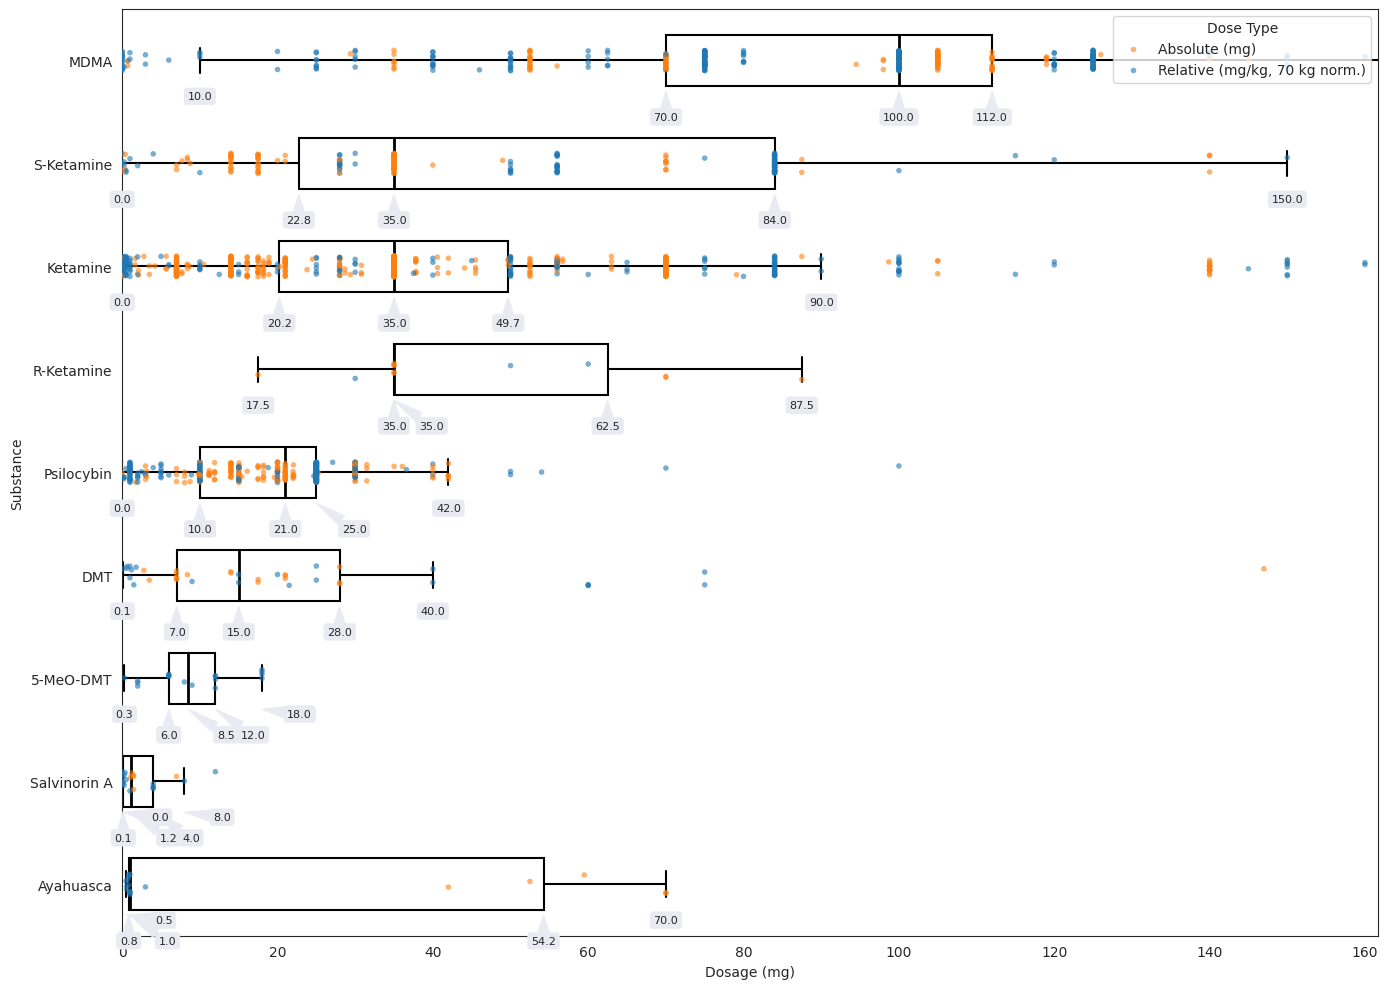

   Substance  Dosage_mg Unit  Study_ID Dose_Type    Norm_Text
38       LSD      0.026   mg      1958  absolute        26 μg
39       LSD      0.013   mg      1958  absolute        13 μg
40       LSD      0.013   mg      1958  absolute  13 or 26 μg
41       LSD      0.026   mg      1958  absolute  13 or 26 μg
44       LSD      0.020   mg      2482  absolute        20 μg


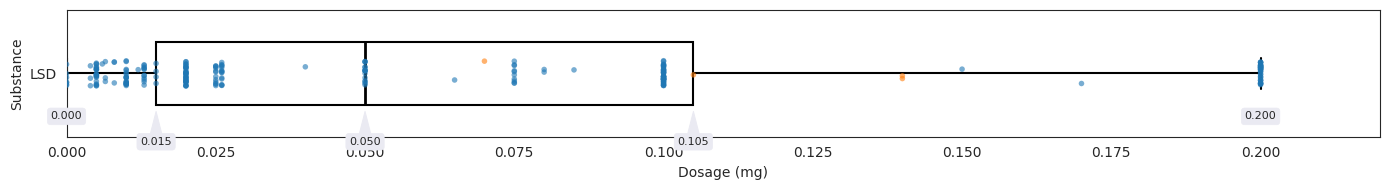

In [ ]:
# print all substances in dosage_ner_data_2025_refined
print("Substances in refined dosage NER data 2025:")

plot_main_substances(df)
plot_lsd(df)
plot_ibogain(df)